In [4]:
import os
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
from tqdm import tqdm

In [11]:
from pathlib import Path

# Go from notebooks/ -> project root
PROJECT_ROOT = Path.cwd().parent

# Path to NTHU training data
train_path = PROJECT_ROOT / "datasets" / "NTHU" / "Multi class" / "train"

# Output folder
OUTPUT_PATH = PROJECT_ROOT / "processed" / "NTHU"

print("Train path:", train_path)
print("Exists:", train_path.exists())

Train path: c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\NTHU\Multi class\train
Exists: True


In [6]:
print(os.listdir(DATASET_PATH))

['drowsy', 'notdrowsy']


In [7]:
print(os.listdir(DATASET_PATH))

['drowsy', 'notdrowsy']


In [9]:
import mediapipe as mp

mp_face_detection = mp.solutions.face_detection

face_detector = mp_face_detection.FaceDetection(
    model_selection=1,
    min_detection_confidence=0.5
)

print("MediaPipe initialized successfully!")

import mediapipe as mp

print("Has solutions:", hasattr(mp, "solutions"))

MediaPipe initialized successfully!
Has solutions: True


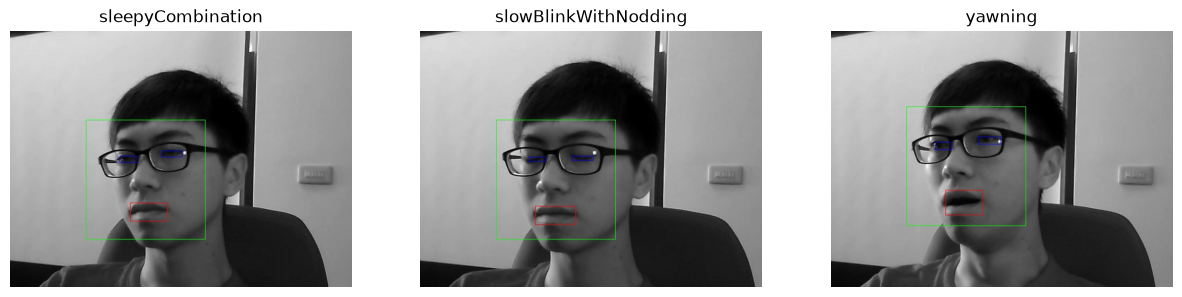

In [12]:
drowsy_path = train_path / "drowsy"

subfolders = [
    "sleepyCombination",
    "slowBlinkWithNodding",
    "yawning"
]

plt.figure(figsize=(15, 5))

for i, folder in enumerate(subfolders):
    img_name = os.listdir(drowsy_path / folder)[0]
    img_path = drowsy_path / folder / img_name

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(folder)
    plt.axis("off")

plt.show()

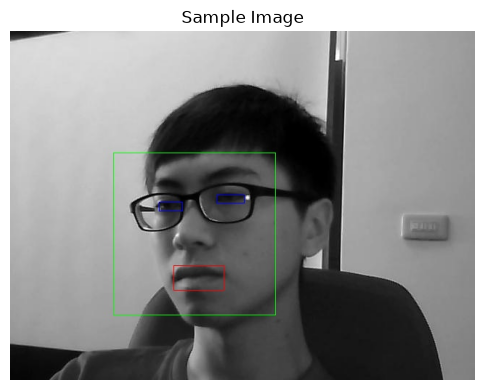

In [13]:
sample_folder = train_path / "drowsy" / "sleepyCombination"

sample_image = os.listdir(sample_folder)[0]
image_path = sample_folder / sample_image

img = cv2.imread(str(image_path))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title("Sample Image")
plt.axis("off")
plt.show()

In [14]:
results = face_detector.process(img_rgb)

if results.detections:
    print("✅ Face detected!")
else:
    print("❌ No face detected.")

✅ Face detected!


c:\Users\clark\OneDrive\Desktop\drowsiness_project\venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


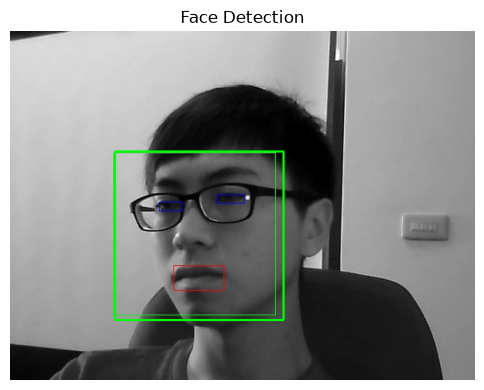

In [15]:
image_copy = img_rgb.copy()

detection = results.detections[0]
bbox = detection.location_data.relative_bounding_box

h, w, _ = image_copy.shape

x = int(bbox.xmin * w)
y = int(bbox.ymin * h)
box_width = int(bbox.width * w)
box_height = int(bbox.height * h)

cv2.rectangle(
    image_copy,
    (x, y),
    (x + box_width, y + box_height),
    (0, 255, 0),
    2
)

plt.figure(figsize=(6, 6))
plt.imshow(image_copy)
plt.title("Face Detection")
plt.axis("off")
plt.show()

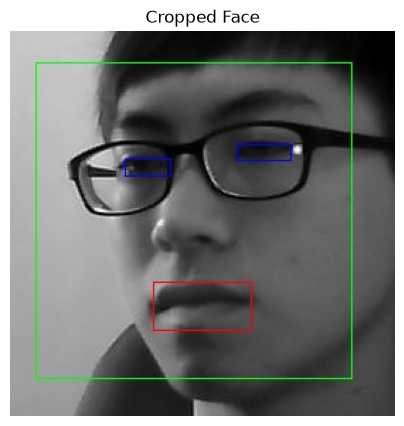

In [16]:
padding = 20

x1 = max(0, x - padding)
y1 = max(0, y - padding)

x2 = min(w, x + box_width + padding)
y2 = min(h, y + box_height + padding)

face_crop = img_rgb[y1:y2, x1:x2]

plt.figure(figsize=(5, 5))
plt.imshow(face_crop)
plt.title("Cropped Face")
plt.axis("off")
plt.show()

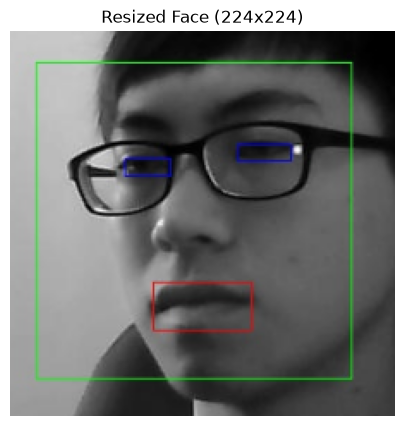

Shape: (224, 224, 3)


In [17]:
face_resized = cv2.resize(face_crop, (224, 224))

plt.figure(figsize=(5, 5))
plt.imshow(face_resized)
plt.title("Resized Face (224x224)")
plt.axis("off")
plt.show()

print("Shape:", face_resized.shape)

In [18]:
os.makedirs(OUTPUT_PATH / "alert", exist_ok=True)

for folder in [
    "sleepyCombination",
    "slowBlinkWithNodding",
    "yawning"
]:
    os.makedirs(OUTPUT_PATH / "drowsy" / folder, exist_ok=True)

print("Output folders created successfully!")

Output folders created successfully!


In [19]:
def preprocess_and_save(input_image_path, output_image_path):
    img = cv2.imread(str(input_image_path))

    if img is None:
        return False

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = face_detector.process(img_rgb)

    if not results.detections:
        return False

    detection = results.detections[0]
    bbox = detection.location_data.relative_bounding_box

    h, w, _ = img_rgb.shape

    x = int(bbox.xmin * w)
    y = int(bbox.ymin * h)
    bw = int(bbox.width * w)
    bh = int(bbox.height * h)

    padding = 20

    x1 = max(0, x - padding)
    y1 = max(0, y - padding)

    x2 = min(w, x + bw + padding)
    y2 = min(h, y + bh + padding)

    face = img_rgb[y1:y2, x1:x2]

    if face.size == 0:
        return False

    face = cv2.resize(face, (224, 224))

    cv2.imwrite(
        str(output_image_path),
        cv2.cvtColor(face, cv2.COLOR_RGB2BGR)
    )

    return True

In [20]:
input_folder = train_path / "drowsy" / "sleepyCombination"
output_folder = OUTPUT_PATH / "drowsy" / "sleepyCombination"

processed = 0
skipped = 0

for img_name in tqdm(os.listdir(input_folder)):
    input_path = input_folder / img_name
    output_path = output_folder / img_name

    success = preprocess_and_save(input_path, output_path)

    if success:
        processed += 1
    else:
        skipped += 1

print("\nFinished!")
print("Processed:", processed)
print("Skipped:", skipped)

100%|██████████| 17756/17756 [06:43<00:00, 44.04it/s] 


Finished!
Processed: 17390
Skipped: 366


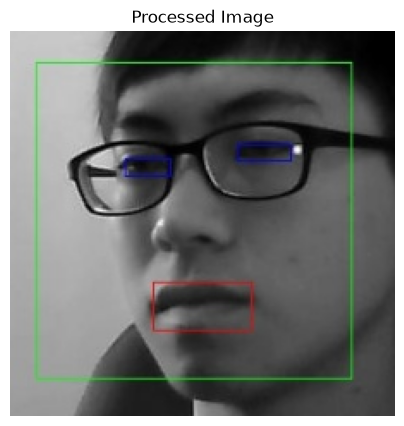

In [22]:
processed_img = os.listdir(output_folder)[0]

img = cv2.imread(str(output_folder / processed_img))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title("Processed Image")
plt.axis("off")
plt.show()

In [23]:
input_folder = train_path / "notdrowsy"
output_folder = OUTPUT_PATH / "alert"

processed = 0
skipped = 0

for img_name in tqdm(os.listdir(input_folder), desc="Processing Alert"):
    input_path = input_folder / img_name
    output_path = output_folder / img_name

    success = preprocess_and_save(input_path, output_path)

    if success:
        processed += 1
    else:
        skipped += 1

print("\n✅ Alert processing complete!")
print("Processed:", processed)
print("Skipped:", skipped)

Processing Alert: 100%|██████████| 30491/30491 [25:18<00:00, 20.08it/s]


✅ Alert processing complete!
Processed: 29646
Skipped: 845


In [24]:
input_folder = train_path / "drowsy" / "sleepyCombination"
output_folder = OUTPUT_PATH / "drowsy" / "sleepyCombination"

processed = 0
skipped = 0

for img_name in tqdm(os.listdir(input_folder), desc="Sleepy Combination"):
    success = preprocess_and_save(
        input_folder / img_name,
        output_folder / img_name
    )

    if success:
        processed += 1
    else:
        skipped += 1

print("\n✅ SleepyCombination complete!")
print("Processed:", processed)
print("Skipped:", skipped)

Sleepy Combination: 100%|██████████| 17756/17756 [13:35<00:00, 21.78it/s] 


✅ SleepyCombination complete!
Processed: 17390
Skipped: 366


In [25]:
input_folder = train_path / "drowsy" / "slowBlinkWithNodding"
output_folder = OUTPUT_PATH / "drowsy" / "slowBlinkWithNodding"

processed = 0
skipped = 0

for img_name in tqdm(os.listdir(input_folder), desc="Slow Blink"):
    success = preprocess_and_save(
        input_folder / img_name,
        output_folder / img_name
    )

    if success:
        processed += 1
    else:
        skipped += 1

print("\n✅ SlowBlinkWithNodding complete!")
print("Processed:", processed)
print("Skipped:", skipped)

Slow Blink: 100%|██████████| 9412/9412 [10:28<00:00, 14.97it/s]


✅ SlowBlinkWithNodding complete!
Processed: 9317
Skipped: 95


In [26]:
input_folder = train_path / "drowsy" / "yawning"
output_folder = OUTPUT_PATH / "drowsy" / "yawning"

processed = 0
skipped = 0

for img_name in tqdm(os.listdir(input_folder), desc="Yawning"):
    success = preprocess_and_save(
        input_folder / img_name,
        output_folder / img_name
    )

    if success:
        processed += 1
    else:
        skipped += 1

print("\n✅ Yawning complete!")
print("Processed:", processed)
print("Skipped:", skipped)

Yawning: 100%|██████████| 8862/8862 [25:45<00:00,  5.73it/s]     



✅ Yawning complete!
Processed: 8568
Skipped: 294


In [27]:
from pathlib import Path

print("\nProcessed image counts:\n")

for folder in [
    OUTPUT_PATH / "alert",
    OUTPUT_PATH / "drowsy" / "sleepyCombination",
    OUTPUT_PATH / "drowsy" / "slowBlinkWithNodding",
    OUTPUT_PATH / "drowsy" / "yawning",
]:
    count = len(list(folder.glob("*")))
    print(f"{folder.name}: {count} images")


Processed image counts:

alert: 29646 images
sleepyCombination: 17390 images
slowBlinkWithNodding: 9317 images
yawning: 8568 images
